In [2]:
import pandas as pd 
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT / "code"))
from plot_of_experiment_data import * 
import matplotlib.pyplot as plt
import warnings
import os
from scipy.stats import shapiro,kruskal,mannwhitneyu
import scikit_posthocs as sp
import numpy as np
warnings.filterwarnings("ignore", message="findfont: Font family 'Arial' not found.")

In [15]:
# Figure S3A,B receptor screening 
fpath = f'data/dose_dp_screening_tarsal_receptor.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
sheets = ['Control','R30A08 > Kir2.1','Gr5a > Kir2.1','Gr5a+R30A08 > Kir2.1','atGRN+Gr5a > Kir2.1','atGRN+R30A08 > Kir2.1']
data_df_receptor = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_receptor[s] = df
    
fpath = f'data/dose_dp_screening_labial.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df_receptor_labial = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_receptor_labial[s] = df

    
fpath = f'data/FMIN_TPN1.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
sheets = ['Control','FMIn > Kir2.1','FMIn + R30A08 > Kir2.1','FMIn - R30A08 > Kir2.1','R30A08 > Kir2.1']
data_df_receptor_FMIN_TPN1 = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
#     df = df.drop('500mM',axis=1)
    data_df_receptor_FMIN_TPN1[s] = df


# Figure S3A

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

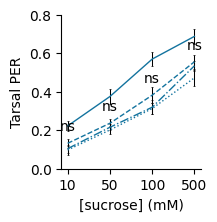

In [7]:
# fig1a: sucrose on leg 
shape = ['o','^','v','d']
linestypes = ['-','--','-.',':']

fig,ax = plt.subplots(1,1,figsize=(1.8,2))
for i,g in enumerate(['Control','R30A08 > Kir2.1','Gr5a > Kir2.1','Gr5a+R30A08 > Kir2.1']):
    plot_dose_dp_PER(ax,data_df_receptor[g],shape=shape[i],linestyle=linestypes[i],**fig_params)
stat_all = plot_statistics_result(ax,[data_df_receptor['R30A08 > Kir2.1'],data_df_receptor['Gr5a+R30A08 > Kir2.1']])

ax.set_ylabel('Tarsal PER',fontsize=10)
ax.set_xlabel('[sucrose] (mM)',fontsize=10)
ax.set_ylim([0,0.8])
ax.set_xticks(list(range(len(data_df_receptor[g].columns))),[x[:-2] for x in data_df_receptor[g].columns],fontsize=10)

# plt.savefig('stGRN.svg',bbox_inches='tight')

# Figure S3B

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

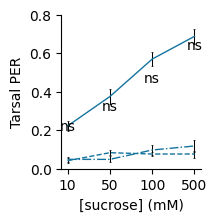

In [6]:
# fig1a: sucrose on leg 
shape = ['o','^','v','d']
linestypes = ['-','--','-.',':']

fig,ax = plt.subplots(1,1,figsize=(1.8,2))
for i,g in enumerate(['Control','atGRN+Gr5a > Kir2.1','atGRN+R30A08 > Kir2.1']):
    plot_dose_dp_PER(ax,data_df_receptor[g],shape=shape[i],linestyle=linestypes[i],**fig_params)
stat_all = plot_statistics_result(ax,[data_df_receptor['R30A08 > Kir2.1'],data_df_receptor['Gr5a+R30A08 > Kir2.1']])

ax.set_ylabel('Tarsal PER',fontsize=10)
ax.set_xlabel('[sucrose] (mM)',fontsize=10)
ax.set_ylim([0,0.8])
ax.set_xticks(list(range(len(data_df_receptor[g].columns))),[x[:-2] for x in data_df_receptor[g].columns],fontsize=10)
# plt.savefig('atGRN+stGRN.svg',bbox_inches='tight')

In [8]:
to_compare = ['R30A08 > Kir2.1','Gr5a > Kir2.1','Gr5a+R30A08 > Kir2.1']
data = [data_df_receptor[x] for x in to_compare]

for conc in [10,50,100,500]:
    # Kruskal-Wallis
    H, p = kruskal(data[0][f'{conc}mM'],data[1][f'{conc}mM'],data[2][f'{conc}mM'])

    print(f"Kruskal-Wallis: H = {H:.3e}, p = {p:.3e}")


Kruskal-Wallis: H = 1.117e+00, p = 5.722e-01
Kruskal-Wallis: H = 1.015e+00, p = 6.019e-01
Kruskal-Wallis: H = 1.233e+00, p = 5.399e-01
Kruskal-Wallis: H = 1.960e+00, p = 3.754e-01


In [9]:
to_compare = ['atGRN+Gr5a > Kir2.1','atGRN+R30A08 > Kir2.1']
data = [data_df_receptor[x] for x in to_compare]

for conc in [10,50,100,500]:
    # Kruskal-Wallis
    U, p = mannwhitneyu(data[0][f'{conc}mM'],data[1][f'{conc}mM'],alternative='two-sided')

    print(f"Mann-Whiney U test: U = {U:.3e}, p = {p:.3e}")


Mann-Whiney U test: U = 1.600e+01, p = 7.980e-01
Mann-Whiney U test: U = 2.600e+01, p = 2.078e-01
Mann-Whiney U test: U = 1.450e+01, p = 6.197e-01
Mann-Whiney U test: U = 1.300e+01, p = 4.649e-01


# Figure S3C

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

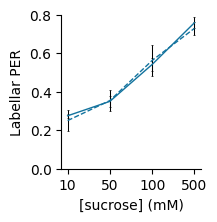

In [12]:
# fig1a: sucrose on leg 
shape = ['o','^','v','d']
linestypes = ['-','--','-.',':']

fig,ax = plt.subplots(1,1,figsize=(1.8,2))
for i,g in enumerate(['sugar','R30A08']):
    plot_dose_dp_PER(ax,data_df_receptor_labial[g],shape=shape[i],linestyle=linestypes[i],**fig_params)
# stat_all = plot_of_experiment_data.plot_statistics_result(ax,[data_df_receptor['R30A08'],data_df_receptor['sugar']])

ax.set_ylabel('Labellar PER',fontsize=10)
ax.set_xlabel('[sucrose] (mM)',fontsize=10)
ax.set_ylim([0,0.8])
ax.set_xticks(list(range(len(data_df_receptor_labial[g].columns))),[x[:-2] for x in data_df_receptor_labial[g].columns],fontsize=10)

# plt.savefig('labial_R30A08.svg',bbox_inches='tight')

In [13]:
to_compare = ['sugar','R30A08']
data = [data_df_receptor_labial[x] for x in to_compare]

for conc in [10,50,100,500]:
    # Kruskal-Wallis
    U, p = mannwhitneyu(data[0][f'{conc}mM'],data[1][f'{conc}mM'],alternative='two-sided')

    print(f"Mann-Whiney U test: U = {U:.3e}, p = {p:.3e}")


Mann-Whiney U test: U = 1.000e+01, p = 1.000e+00
Mann-Whiney U test: U = 1.000e+01, p = 1.000e+00
Mann-Whiney U test: U = 8.500e+00, p = 8.049e-01
Mann-Whiney U test: U = 1.250e+01, p = 6.022e-01


# Figure S3D

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

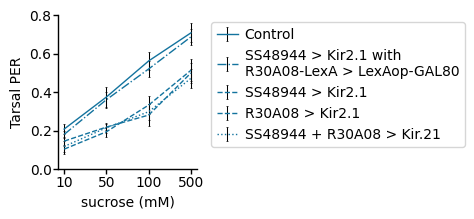

In [16]:
# fig1a: sucrose on leg 
groups = [
    'Control',
    'FMIn - R30A08 > Kir2.1',
    'FMIn > Kir2.1',
    'R30A08 > Kir2.1',
    'FMIn + R30A08 > Kir2.1'
]
labels = ['Control',
         'SS48944 > Kir2.1 with\nR30A08-LexA > LexAop-GAL80',
         'SS48944 > Kir2.1',
         'R30A08 > Kir2.1',
         'SS48944 + R30A08 > Kir.21'
        ]

shape = ['o', 's', '^',  'v','D']
linestyles = ['solid', 'dashdot','dashed',  'dashed', 'dotted']

fig,ax = plt.subplots(1,1,figsize=(1.8,2))
for i,g in enumerate(groups):
    plot_dose_dp_PER(ax,data_df_receptor_FMIN_TPN1[g],shape=shape[i],linestyle=linestyles[i],**fig_params)
# stat_all = plot_of_experiment_data.plot_statistics_result(ax,[data_df_receptor['R30A08 > Kir2.1'],data_df_receptor['FMIN > Kir2.1']])

ax.set_ylabel('Tarsal PER',fontsize=10)
ax.set_xlabel('sucrose (mM)',fontsize=10)
ax.set_ylim([0,0.8])
ax.set_xticks(list(range(len(data_df_receptor_FMIN_TPN1[g].columns))),[x[:-2] for x in data_df_receptor_FMIN_TPN1[g].columns],fontsize=10)

ax.legend(labels,ncol=1,handlelength=1.5, columnspacing=.5,handletextpad=.5,loc=2,bbox_to_anchor=(1.05,1))
for spine in ax.spines.values():
    spine.set_linewidth(1)

# Tick thickness
ax.tick_params(
    axis='both',
    width=1,
    pad=1
)

# plt.savefig('FMIN_TPN1.svg',bbox_inches='tight')

In [20]:
cond = data_df_receptor_FMIN_TPN1['Control'].columns
c = data_df_receptor_FMIN_TPN1['FMIn > Kir2.1'][cond].dropna()
d = data_df_receptor_FMIN_TPN1['R30A08 > Kir2.1'][cond].dropna()
e = data_df_receptor_FMIN_TPN1['FMIn + R30A08 > Kir2.1'][cond].dropna()

stat, p = kruskal(c, d, e)
print(cond, 'three silencing conditions:', stat, p)

Index(['10mM', '50mM', '100mM', '500mM'], dtype='object') three silencing conditions: [1.14057571 0.15797788 0.57032428 0.18560606] [0.56536267 0.92405014 0.75189233 0.911373  ]


In [21]:
to_compare = ['Control','FMIn - R30A08 > Kir2.1']
data = [data_df_receptor_FMIN_TPN1[x] for x in to_compare]

for conc in [10,50,100,500]:
    # Kruskal-Wallis
    U, p = mannwhitneyu(data[0][f'{conc}mM'],data[1][f'{conc}mM'],alternative='two-sided')

    print(f"Mann-Whiney U test: U = {U:.3e}, p = {p:.3e}")


Mann-Whiney U test: U = 2.300e+01, p = 4.566e-01
Mann-Whiney U test: U = 2.000e+01, p = 8.068e-01
Mann-Whiney U test: U = 2.150e+01, p = 6.255e-01
Mann-Whiney U test: U = 2.000e+01, p = 8.079e-01


In [22]:
to_compare = ['Control','FMIn > Kir2.1']
data = [data_df_receptor_FMIN_TPN1[x] for x in to_compare]

for conc in [10,50,100,500]:
    # Kruskal-Wallis
    U, p = mannwhitneyu(data[0][f'{conc}mM'],data[1][f'{conc}mM'],alternative='two-sided')

    print(f"Mann-Whiney U test: U = {U:.3e}, p = {p:.3e}")


Mann-Whiney U test: U = 3.100e+01, p = 4.271e-02
Mann-Whiney U test: U = 3.200e+01, p = 2.919e-02
Mann-Whiney U test: U = 3.300e+01, p = 1.937e-02
Mann-Whiney U test: U = 3.100e+01, p = 4.345e-02
